# Phase 1: Data Understanding & Profiling
This notebook covers the initial phase of analytics to understand the structure, data quality, relationships, and basic profiles of the provided datasets.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

sns.set_theme(style="whitegrid")
RAW_DIR = r"c:\PYTHON p45\New_Project\data\raw"
files = glob.glob(os.path.join(RAW_DIR, "*.csv"))
csv_files = {os.path.basename(f): f for f in files}
print(f"Found {len(csv_files)} CSV files in {RAW_DIR}")

Found 8 CSV files in c:\PYTHON p45\New_Project\data\raw


## 1. Dataset Inventory & Structural Observations
Loading datasets and determining rows, columns, memory usage, missing values, and duplicate rows.

In [3]:
dataframes = {name: pd.read_csv(path) for name, path in csv_files.items()}

inventory = []
for name, df in dataframes.items():
    inventory.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

inventory_df = pd.DataFrame(inventory).sort_values("Rows", ascending=False)
display(inventory_df)

,Dataset,Rows,Columns,Memory (MB),Missing Values,Duplicate Rows
1,charging_sessions.csv,500000,17,273.52,0,0
4,station_hourly_metrics.csv,498253,19,127.35,0,0
5,traffic.csv,498253,6,104.19,0,0
7,weather.csv,17520,10,6.17,0,0
6,vehicles.csv,10000,4,1.37,0,0
3,stations.csv,5000,20,3.25,0,0
0,calendar.csv,731,9,0.20,0,0
2,data_dictionary.csv,31,5,0.01,0,0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5840\275437270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inventory_df, x="Rows", y="Dataset", palette="viridis")


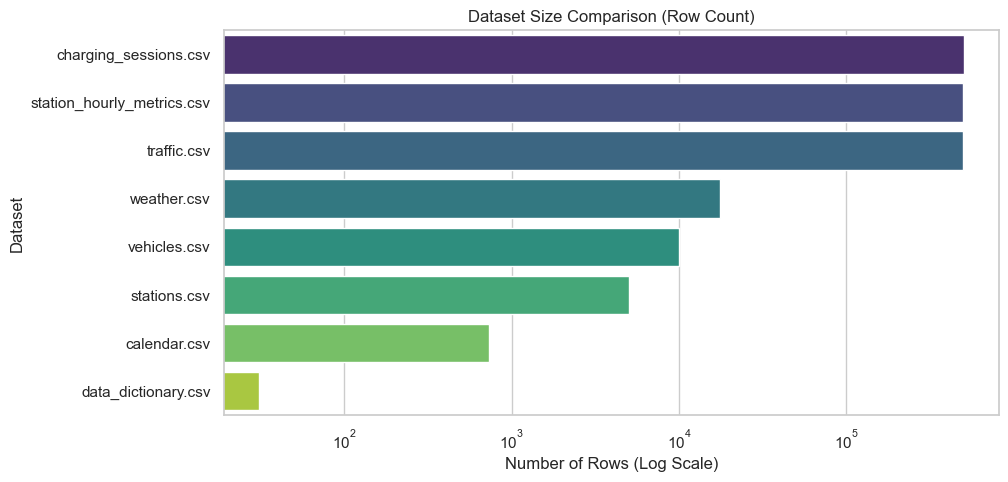

In [4]:
plt.figure(figsize=(10, 5))
sns.barplot(data=inventory_df, x="Rows", y="Dataset", palette="viridis")
plt.title("Dataset Size Comparison (Row Count)")
plt.xscale("log")
plt.xlabel("Number of Rows (Log Scale)")
plt.show()

## 2. Table Roles and Relationships
- **`charging_sessions.csv`**: Fact Table (Grain: individual charging session).
- **`station_hourly_metrics.csv`**: Derived / Aggregated Fact Table (Grain: station-hour). 
- **`stations.csv`**: Dimension Table (Details about charging locations/infrastructure). Key: `Station_ID`.
- **`vehicles.csv`**: Dimension Table (Details on cars using the chargers). Key: `Vehicle_ID`.
- **`weather.csv`**: Context Table (Weather states by Location/Date/Hour). 
- **`traffic.csv`**: Context Table (Traffic states by Station/Date/Hour).
- **`calendar.csv`**: Date Dimension Table.
- **`data_dictionary.csv`**: Metadata.

## 3. Temporal Coverage

In [5]:
temporal_info = []
for name in ['calendar.csv', 'station_hourly_metrics.csv', 'weather.csv', 'traffic.csv']:
    if name in dataframes:
        df = dataframes[name]
        if 'Date' in df.columns:
            dates = pd.to_datetime(df['Date'])
            temporal_info.append({'Dataset': name, 'Start Date': dates.min().date(), 'End Date': dates.max().date()})

if 'charging_sessions.csv' in dataframes:
    df = dataframes['charging_sessions.csv']
    dates = pd.to_datetime(df['Start_Time'])
    temporal_info.append({'Dataset': 'charging_sessions.csv', 'Start Date': dates.min().date(), 'End Date': dates.max().date()})

temp_df = pd.DataFrame(temporal_info)
display(temp_df)

,Dataset,Start Date,End Date
0,calendar.csv,2024-01-01,2025-12-31
1,station_hourly_metrics.csv,2024-01-01,2025-12-30
2,weather.csv,2024-01-01,2025-12-30
3,traffic.csv,2024-01-01,2025-12-30
4,charging_sessions.csv,2024-01-01,2025-12-30


## 4. Notable Data Quality Observations
Documenting anomalies based on basic profiling.

In [6]:
print("Checking for negative lat/lon values in stations.csv:")
stations = dataframes['stations.csv']
print(f"Negative Latitudes: {(stations['Latitude'] < 0).sum()} / {len(stations)}")
print(f"Negative Longitudes: {(stations['Longitude'] < 0).sum()} / {len(stations)}")

print("\nChecking weather.csv for potential extreme values:")
weather = dataframes['weather.csv']
print(f"Negative temperatures (C): {(weather['Temperature_C'] < 0).sum()} occurrences.")

print("\nChecking context data completeness:")
print(f"Unique cities in stations.csv: {stations['City'].unique()}")
print(f"Unique states in stations.csv: {stations['State'].unique()}")


Checking for negative lat/lon values in stations.csv:
Negative Latitudes: 1132 / 5000
Negative Longitudes: 2017 / 5000

Checking weather.csv for potential extreme values:
Negative temperatures (C): 37 occurrences.

Checking context data completeness:
Unique cities in stations.csv: ['Unknown']
Unique states in stations.csv: ['Unknown']


## 5. Important Business Variables
- **Demand Analytics**: `Sessions_Count`, `Charging_Duration_Min`, `Energy_Delivered_kWh`, `Traffic_Volume`
- **Station Performance**: `Utilization_Rate`, `Capacity_Utilization`, `Revenue_USD`, `Peak_Power_kW`
- **Customer Behavior**: `Wait_Time_Min`, `Queue_Length`, `Initial_SOC_pct`, `Final_SOC_pct`
- **External Factors**: `Temperature_C`, `Congestion_Level`, `Rainfall_mm`, `Weather_Condition`
- **Infrastructure Capacity**: `Charger_Type`, `Max_Station_Power_kW`, `Number_of_Chargers`

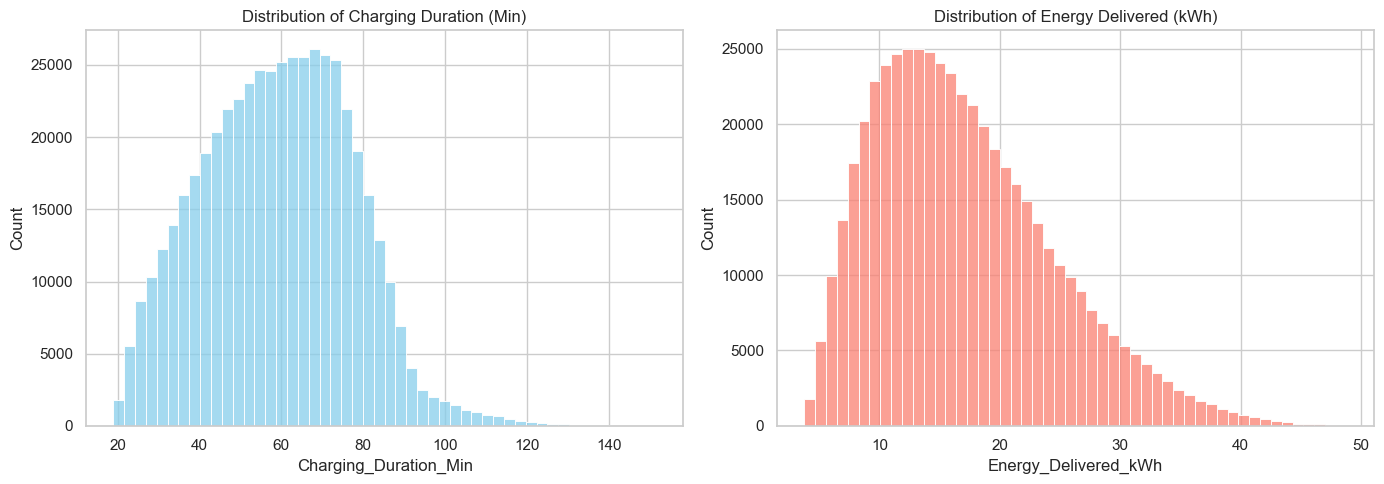

In [7]:
# Visualizing distributions of primary demand metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(dataframes['charging_sessions.csv']['Charging_Duration_Min'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Charging Duration (Min)')

sns.histplot(dataframes['charging_sessions.csv']['Energy_Delivered_kWh'], bins=50, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Energy Delivered (kWh)')

plt.tight_layout()
plt.show()